In [ ]:
#installing the kaggle library
!pip install kaggle

In [ ]:
#configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

importing the dog vs cat dataset from kaggle

In [ ]:
#kaggle api
!kaggle competitions download -c dogs-vs-cats

 99% 805M/812M [00:11<00:00, 138MB/s]
100% 812M/812M [00:11<00:00, 71.5MB/s]


In [ ]:
!ls

dogs-vs-cats.zip  kaggle.json  sample_data


In [ ]:
#extractiong the compressed dataset
from zipfile import ZipFile

dataset = "/content/dogs-vs-cats.zip"

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
#extractiong the compressed dataset
from zipfile import ZipFile

dataset = "/content/train.zip"

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:

import os
#counting the number of files in train folder
path, dirs, files = next(os.walk("/content/train"))
file_count = len(files)
print("Number of images:",file_count)

Number of images: 25000


printing the name of images

In [ ]:
file_names = os.listdir("/content/train")
print(file_names)

['dog.4280.jpg', 'cat.10551.jpg', 'cat.10922.jpg', 'dog.8855.jpg', 'cat.2610.jpg', 'cat.568.jpg', 'cat.2561.jpg', 'dog.9069.jpg', 'dog.12291.jpg', 'cat.2934.jpg', 'cat.5639.jpg', 'dog.3253.jpg', 'cat.2301.jpg', 'cat.10084.jpg', 'cat.7519.jpg', 'cat.3530.jpg', 'dog.9645.jpg', 'dog.2740.jpg', 'cat.4951.jpg', 'dog.1160.jpg', 'dog.2544.jpg', 'cat.7524.jpg', 'cat.10992.jpg', 'cat.6396.jpg', 'dog.4068.jpg', 'dog.1935.jpg', 'cat.7443.jpg', 'dog.4501.jpg', 'dog.739.jpg', 'dog.7421.jpg', 'dog.6741.jpg', 'cat.1544.jpg', 'dog.4119.jpg', 'dog.8204.jpg', 'cat.5015.jpg', 'dog.8081.jpg', 'dog.6691.jpg', 'dog.5946.jpg', 'cat.12094.jpg', 'cat.1909.jpg', 'cat.2374.jpg', 'cat.7234.jpg', 'dog.5595.jpg', 'cat.7513.jpg', 'cat.3464.jpg', 'cat.6628.jpg', 'cat.6127.jpg', 'dog.4638.jpg', 'dog.12458.jpg', 'dog.885.jpg', 'cat.9284.jpg', 'cat.2871.jpg', 'dog.6925.jpg', 'cat.9681.jpg', 'dog.9265.jpg', 'dog.5157.jpg', 'dog.11342.jpg', 'dog.8649.jpg', 'cat.7315.jpg', 'cat.4906.jpg', 'dog.10050.jpg', 'dog.4312.jpg', '

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

displaying the images of dogs and cats

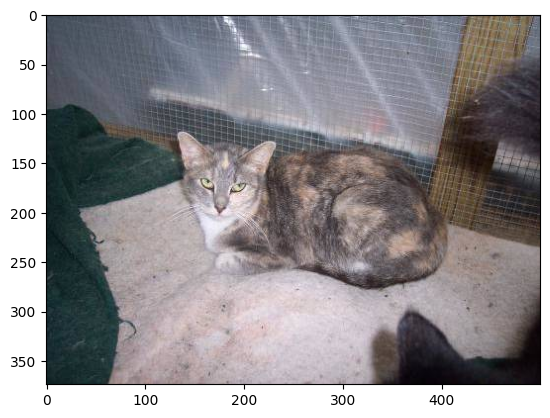

In [ ]:
#display cat image
img = mpimg.imread("/content/train/cat.6666.jpg")
imgplot = plt.imshow(img)
plt.show()

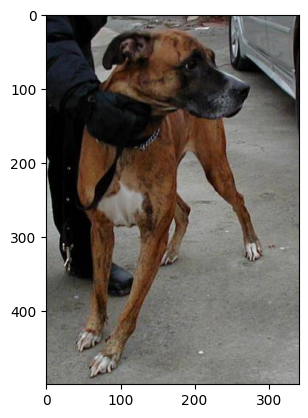

In [ ]:
#display dog image
img = mpimg.imread("/content/train/dog.6588.jpg")
imgplot = plt.imshow(img)
plt.show()

In [ ]:
file_names = os.listdir("/content/train")

for i in range(5):

  name = file_names[i]
  print(name[0:3])


dog
cat
cat
dog
cat


In [ ]:
file_names = os.listdir('/content/train/')

dog_count = 0
cat_count = 0

for img_file in file_names:

  name = img_file[0:3]

  if name == 'dog':
    dog_count += 1

  else:
    cat_count += 1

print('Number of dog images =', dog_count)
print('Number of cat images =', cat_count)

Number of dog images = 12500
Number of cat images = 12500


resize

In [ ]:
#creating a directory for resized images
os.mkdir('/content/image resized')

In [18]:
original_folder = "/content/train/"
resized_folder = "/content/image resized/"

# Iterate over all files in the original_folder
for filename in os.listdir(original_folder):

  img_path = original_folder + filename

  img = Image.open(img_path)
  img = img.resize((224,224))
  img = img.convert('RGB')

  newImgPath = resized_folder+filename
  img.save(newImgPath)

In [ ]:
#dislay resized dog image
img = mpimg.imread("/content/image resized/dog.1000.jpg")
imgplt = plt.imshow(img)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/image resized/dog.1000.jpg'

In [ ]:
#dislay resized cat image
img = mpimg.imread("/content/image resized/cat.6664.jpg")
imgplt = plt.imshow(img)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/image resized/cat.6664.jpg'

In [ ]:
filenames = os.listdir("/content/image resized/")

labels = []

for file_name in filenames:

  label = file_name[0:3]

  if label == 'dog':
    labels.append(1)

  else:
    labels.append(0)

In [ ]:
print(filenames[0:5])
print(len(filenames))

['dog.5595.jpg', 'dog.8004.jpg', 'dog.2863.jpg', 'cat.7288.jpg', 'dog.4092.jpg']
25000


In [ ]:
print(labels[0:5])
print(len(labels))

[1, 1, 1, 0, 1]
25000


In [ ]:
# counting the images of dogs and cats out of 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[12500 12500]


converting all the resized images to numpy arrays

In [ ]:
import cv2
import glob

In [ ]:
image_directory = "/content/image resized/"
image_extension = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + "*." + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])


In [ ]:
print(dog_cat_images)

[[[[ 79  68  71]
   [ 84  73  75]
   [ 84  71  73]
   ...
   [203 178 162]
   [197 171 155]
   [187 161 145]]

  [[ 73  61  67]
   [ 75  64  67]
   [ 75  64  66]
   ...
   [202 177 161]
   [197 171 155]
   [189 163 147]]

  [[ 66  55  63]
   [ 70  60  66]
   [ 72  63  66]
   ...
   [201 176 160]
   [197 172 156]
   [190 165 149]]

  ...

  [[184 166 159]
   [187 169 162]
   [190 172 165]
   ...
   [215 192 176]
   [212 189 173]
   [209 186 170]]

  [[188 169 161]
   [190 171 163]
   [192 173 165]
   ...
   [213 190 174]
   [208 185 169]
   [203 180 164]]

  [[194 174 163]
   [195 175 164]
   [196 176 165]
   ...
   [213 190 174]
   [206 183 167]
   [201 178 162]]]


 [[[149 161 203]
   [142 154 196]
   [126 140 182]
   ...
   [145 164 197]
   [142 161 194]
   [140 159 192]]

  [[152 164 206]
   [143 155 197]
   [124 138 180]
   ...
   [145 164 197]
   [143 162 195]
   [141 160 193]]

  [[151 163 205]
   [138 150 192]
   [117 131 173]
   ...
   [138 158 189]
   [137 157 188]
   [136 156

In [ ]:
print(dog_cat_images.ndim)

4


In [ ]:
print(dog_cat_images.shape)

(25000, 224, 224, 3)


In [ ]:
X = dog_cat_images
Y = np.asarray(labels)

test train split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(25000, 224, 224, 3) (20000, 224, 224, 3) (5000, 224, 224, 3)


1600 = training images
400 = test images

In [ ]:
#scaling the data

X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [ ]:
print(X_train_scaled)